In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('example_data.csv')
df

,A,B
0,1,2
1,2,3
2,3,8
3,4,5
4,5,6
5,560,7
6,2,8
7,3,9
8,3,0
9,4,3


In [ ]:
def three_sigma(ser1):
    # 计算均值
    mean_value = ser1.mean()
    # 计算标准差
    std_value = ser1.std()
    # 判断是否为异常值
    # 定义一个规则，用于识别数据中的异常值
    # 该规则使用3-sigma原则（即标准差原则）
    # 当数据点偏离平均值超过3个标准差时，被视为异常值
    rule = (ser1 <= mean_value - 3 * std_value) | (ser1 >= mean_value + 3 * std_value)
    # 使用NumPy的arange函数创建一个从0到ser1长度-1的整数数组，然后根据rule规则进行索引筛选
    index = np.arange(ser1.shape[0])[rule]  # 获取符合rule条件的索引值
    # 获取指定索引位置的值
    outrange = ser1.iloc[index]  # 使用iloc方法从ser1 Series中获取index位置对应的值
    return outrange

In [ ]:
# 调用three_sigma函数，对DataFrame中'A'列的数据进行三倍标准差分析
# three_sigma函数通常用于检测数据中的异常值，基于正态分布原理
# 计算规则：超出均值±3倍标准差的数据点被视为异常值
three_sigma(df['A'])

5    560
Name: A, dtype: int64

In [6]:
# 调用three_sigma函数，对DataFrame中列名为'B'的数据进行三倍标准差分析
three_sigma(df['B'])

Series([], Name: B, dtype: int64)

In [7]:
df = pd.DataFrame({'A': [1, 2, 3, 4],
                   'B': [2, 3, 5, 2],
                   'C': [1, 4, 7, 4],
                   'D': [1, 5, 30, 3]})

In [8]:
# 导入matplotlib库中的pyplot模块，并将其简称为plt，用于绘图
import matplotlib.pyplot as plt
# 在Jupyter Notebook或类似环境中使用此命令，可以直接在notebook中显示图形，而不是弹出新窗口
%matplotlib inline

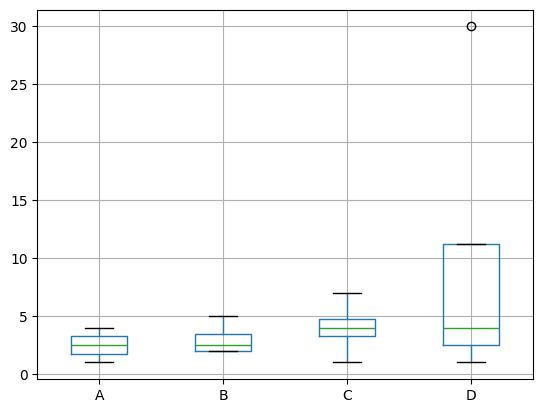

In [11]:
# 使用pandas库的DataFrame和matplotlib库进行数据可视化
df.boxplot(column=['A', 'B', 'C', 'D'])  # 绘制箱线图，展示A、B、C、D四列数据的分布情况
plt.show()  # 显示图形

In [ ]:
# 这里的用标准差方式查看D类是否存在异常值
three_sigma(df['D'])

Series([], Name: D, dtype: int64)

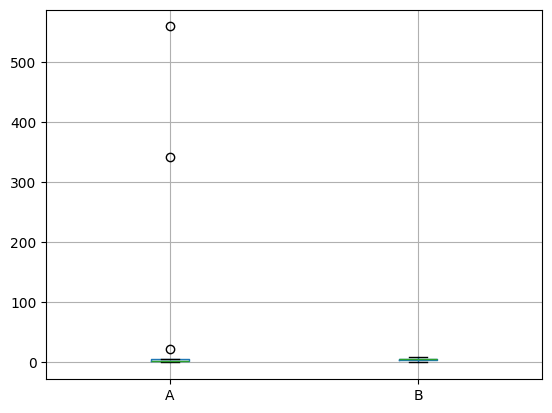

In [14]:
pd.read_csv('example_data.csv').boxplot(column=['A', 'B'])  # 绘制箱线图，展示A、B、C、D四列数据的分布情况
plt.show()  # 显示图形

In [ ]:
# 导入pandas库
import pandas as pd
# 创建一个DataFrame，包含菜谱名和价格两列数据
# 菜谱名列包含5个菜品名称
# 价格列对应每个菜品的价钱
df = pd.DataFrame ({'菜谱名': ['红烧肉', '铁板鱿鱼', 
                    '小炒肉', '干锅鸭掌', '酸菜鱼'],
                    '价格': [38, 25, 26, 388, 35]})
# 使用replace方法替换DataFrame中的值
# 将价格388替换为38.8
# 注意：此操作不会直接修改原始DataFrame，需要重新赋值才能生效
df.replace(to_replace=388,value=38.8)

,菜谱名,价格
0,红烧肉,38.0
1,铁板鱿鱼,25.0
2,小炒肉,26.0
3,干锅鸭掌,38.8
4,酸菜鱼,35.0


In [18]:
# 数据合并
# 轴向堆叠数据
df1 = pd.DataFrame({'A': ['A0', 'A0', 'A1'],
                    'B': ['B0', 'B0', 'B1']})
df1

,A,B
0,A0,B0
1,A0,B0
2,A1,B1


In [20]:
df2 = pd.DataFrame({'C': ['C0', 'C0', 'C1', 'C3'],
                    'D': ['D0', 'D2', 'D2', 'D3']})
df2

,C,D
0,C0,D0
1,C0,D2
2,C1,D2
3,C3,D3


In [ ]:
# 使用pandas库中的concat函数进行数据合并
# 将两个DataFrame对象df1和df2沿axis=1（列方向）进行合并
# join参数设置为'outer'，表示保留所有列，如果某个DataFrame中没有某列则填充NaN值
pd.concat([df1, df2], join='outer', axis=1)

,A,B,C,D
0,A0,B0,C0,D0
1,A0,B0,C0,D2
2,A1,B1,C1,D2
3,NaN,NaN,C3,D3


In [28]:
# 使用pandas库中的concat函数进行数据框的合并操作
# 参数说明：
# [df1, df2] - 需要合并的数据框列表，这里是要合并df1和df2两个数据框
# join='inner' - 设置合并方式为内连接，只保留两个数据框中都存在的键（列名或索引）
# axis=0 - 设置合并方向为纵向合并（按行），即一个数据框在另一个数据框的下方
pd.concat([df1, df2], join='inner', axis=0, ignore_index=True)

""
0
1
2
3
4
5
6


# 主键合并

In [32]:
left = pd.DataFrame({'key':['K0','K1','K2'],
                       'A':['A0','A1','A2'],
                        'B':['B0','B1','B2']})
left

,key,A,B
0,K0,A0,B0
1,K1,A1,B1
2,K2,A2,B2


In [33]:
right = pd.DataFrame({'key':['K0','K1','K2','K3'],
                         'C':['C0','C1','C2','C3'],
                         'D':['D0','D1','D2','D3']})
right

,key,C,D
0,K0,C0,D0
1,K1,C1,D1
2,K2,C2,D2
3,K3,C3,D3


In [ ]:
# 使用pandas库中的merge函数进行合并操作
# 这是一个外连接(outer join)合并，会保留两个数据框中的所有行
pd.merge(left, right, how='outer')

,key,A,B,C,D
0,K0,A0,B0,C0,D0
1,K1,A1,B1,C1,D1
2,K2,A2,B2,C2,D2
3,K3,NaN,NaN,C3,D3


In [ ]:
# 使用pandas库中的merge函数进行数据合并操作
pd.merge(left, right, how='left')  # 执行左连接合并，保留左表(left)的所有数据，右表(right)中匹配的数据会被合并，不匹配的部分则为NaN

,key,A,B,C,D
0,K0,A0,B0,C0,D0
1,K1,A1,B1,C1,D1
2,K2,A2,B2,C2,D2


In [ ]:
# 使用pandas库中的merge函数进行数据合并操作
# 将左侧数据框(left)和右侧数据框(right)进行基于键的合并
# how='right'表示执行右连接，即保留右侧数据框中的所有行，仅在左侧数据框中找到匹配的行时才合并
pd.merge(left, right, how='right')

,key,A,B,C,D
0,K0,A0,B0,C0,D0
1,K1,A1,B1,C1,D1
2,K2,A2,B2,C2,D2
3,K3,NaN,NaN,C3,D3


In [39]:
left = pd.DataFrame({'key':['K0','K1','K2'],
                       'A':['A0','A1','A2'],
                       'B':['B0','B1','B2']})
left

,key,A,B
0,K0,A0,B0
1,K1,A1,B1
2,K2,A2,B2


In [40]:
right = pd.DataFrame({'key':['K0','K5','K2','K4'],
                         'B':['B0','B1','B2','B5'],
                         'C':['C0','C1','C2','C3'],
                         'D':['D0','D1','D2','D3']})
right

,key,B,C,D
0,K0,B0,C0,D0
1,K5,B1,C1,D1
2,K2,B2,C2,D2
3,K4,B5,C3,D3


In [45]:
pd.merge(left, right, on=['key','B'])

,key,A,B,C,D
0,K0,A0,B0,C0,D0
1,K2,A2,B2,C2,D2


## 根据索引合并数据

In [ ]:
# 上面的是根据列的key合并，但是这里是索引
left = pd.DataFrame({'A': ['A0', 'A1', 'A2'],
                        'B': ['B0', 'B1', 'B2'],
                      'key': ['K0', 'K1', 'K2']})
left

,A,B,key
0,A0,B0,K0
1,A1,B1,K1
2,A2,B2,K2


In [47]:
right = pd.DataFrame({'C': ['C0', 'C1','C2'],
                         'D': ['D0', 'D1','D2']},
                        index=['K0', 'K1','K2'])
right

,C,D
K0,C0,D0
K1,C1,D1
K2,C2,D2


In [49]:
# 使用左连接(left join)合并两个数据集
# left: 左侧数据集，作为基准表
# right: 右侧数据集，将被连接到左侧数据集
# how: 连接方式，这里使用"left"表示左连接，保留左侧数据集的所有记录
# on: 连接键，指定用于连接的列名，这里是"key"
left.join(right, how="left", on="key")

,A,B,key,C,D
0,A0,B0,K0,C0,D0
1,A1,B1,K1,C1,D1
2,A2,B2,K2,C2,D2


# 合并重叠的数据

In [50]:
left = pd.DataFrame({'A': [np.nan, 'A1', 'A2', 'A3'],
                        'B': [np.nan, 'B1', np.nan, 'B3'],
                        'key': ['K0', 'K1', 'K2', 'K3']})
left


,A,B,key
0,NaN,NaN,K0
1,A1,B1,K1
2,A2,NaN,K2
3,A3,B3,K3


In [51]:
right = pd.DataFrame({'A': ['C0', 'C1','C2'],
                         'B': ['D0', 'D1','D2']},
                         index=[1,0,2])
right

,A,B
1,C0,D0
0,C1,D1
2,C2,D2


In [ ]:
# 使用right中的值填充left中的缺失值
# 如果left中存在缺失值(NaN)，则用right中对应位置的值替换
# 如果left和right都存在缺失值，则结果仍为缺失值
left.combine_first(right)

,A,B,key
0,C1,D1,K0
1,A1,B1,K1
2,A2,D2,K2
3,A3,B3,K3
